In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [7]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

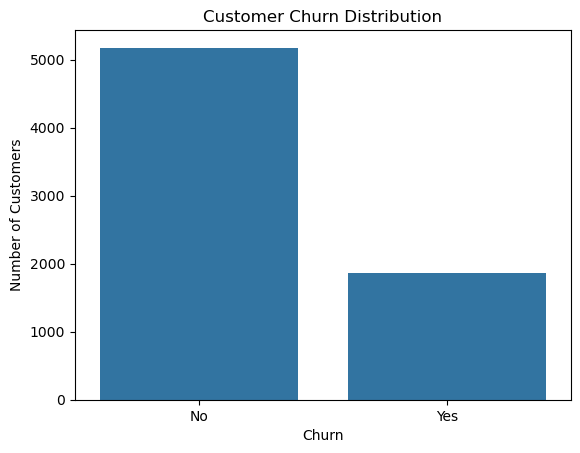

In [8]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')

plt.show()

In [9]:
df[['tenure', 'MonthlyCharges']].describe()

,tenure,MonthlyCharges
count,7043.000000,7043.000000
mean,32.371149,64.761692
std,24.559481,30.090047
min,0.000000,18.250000
25%,9.000000,35.500000
50%,29.000000,70.350000
75%,55.000000,89.850000
max,72.000000,118.750000


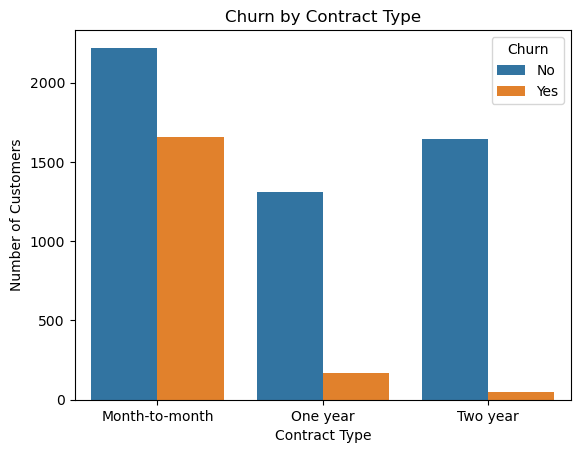

In [10]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Churn by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Number of Customers')

plt.show()

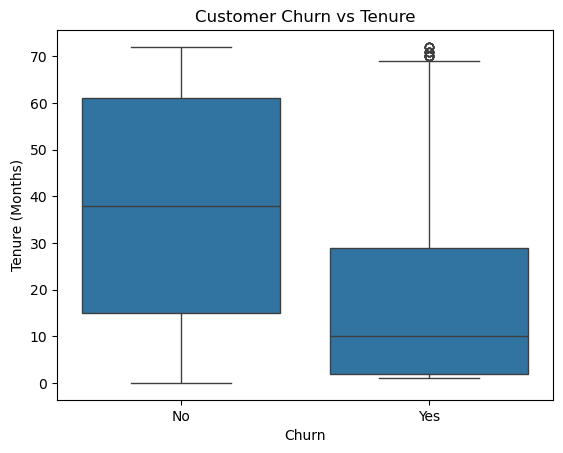

In [11]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Customer Churn vs Tenure')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

plt.show()

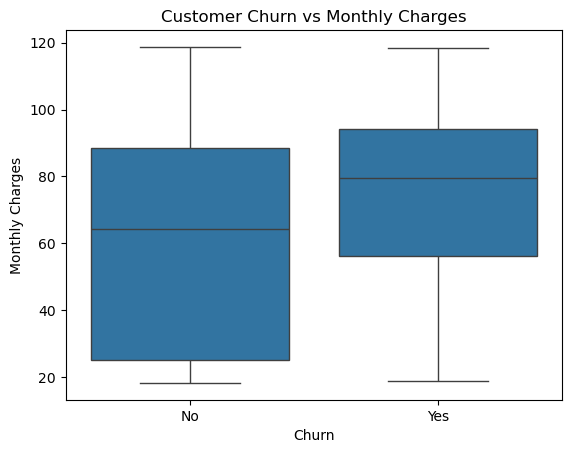

In [12]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Customer Churn vs Monthly Charges')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.show()

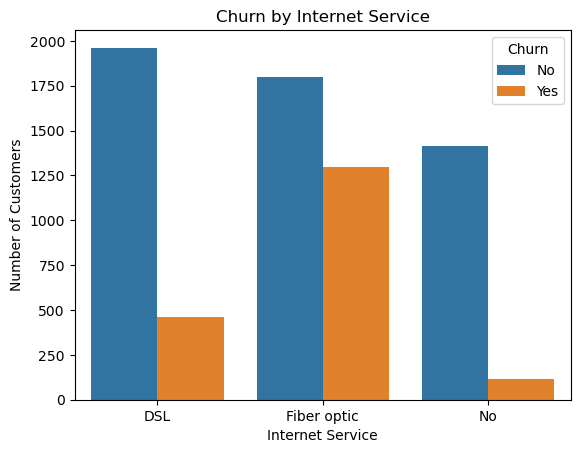

In [13]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title('Churn by Internet Service')
plt.xlabel('Internet Service')
plt.ylabel('Number of Customers')

plt.show()

In [14]:
df_clean = df.copy()

In [15]:
df_clean['TotalCharges'].value_counts().head()

TotalCharges
         11
20.2     11
19.75     9
20.05     8
19.9      8
Name: count, dtype: int64

In [16]:
df_clean['TotalCharges'].isna().sum()

np.int64(0)

In [17]:
(df_clean['TotalCharges'] == ' ').sum()

np.int64(11)

In [18]:
df_clean['TotalCharges'] = pd.to_numeric(
    df_clean['TotalCharges'],
    errors='coerce'
)

In [19]:
df_clean.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [20]:
df_clean = df_clean.dropna()

In [21]:
df_clean.isnull().sum().sum()

np.int64(0)

In [22]:
df_clean = df_clean.drop('customerID', axis=1)

In [23]:
df_clean['Churn'] = df_clean['Churn'].map({'No': 0, 'Yes': 1})

In [24]:
df_clean['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [25]:
X = df_clean.drop('Churn', axis=1)
y = df_clean['Churn']

In [26]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 19)
y shape: (7032,)


In [27]:
X = pd.get_dummies(X, drop_first=True)

In [28]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 30)
Testing data: (1407, 30)


In [31]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
from sklearn.linear_model import LogisticRegression

In [33]:
logistic_model = LogisticRegression(max_iter=1000)

In [34]:
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
y_pred = logistic_model.predict(X_test_scaled)

In [36]:
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

In [37]:
accuracy = accuracy_score(y_test, y_pred)

In [38]:
recall = recall_score(y_test, y_pred)

In [39]:
roc_auc = roc_auc_score(y_test, y_prob)

In [40]:
print("Logistic Regression Results")
print("--------------------------")
print("Accuracy :", round(accuracy, 4))
print("Recall   :", round(recall, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Logistic Regression Results
--------------------------
Accuracy : 0.8038
Recall   : 0.5749
ROC-AUC  : 0.8357


In [41]:
from sklearn.ensemble import RandomForestClassifier

In [42]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [43]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
rf_pred = rf_model.predict(X_test)

In [45]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [46]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Recall   :", round(rf_recall, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.7868
Recall   : 0.508
ROC-AUC  : 0.8181


In [50]:
!pip install xgboost

In [55]:
from xgboost import XGBClassifier

In [56]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

In [57]:
xgb_model.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [58]:
xgb_pred = xgb_model.predict(X_test)

In [59]:
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [60]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print("XGBoost Results")
print("----------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Recall   :", round(xgb_recall, 4))
print("ROC-AUC  :", round(xgb_roc_auc, 4))

XGBoost Results
----------------
Accuracy : 0.7946
Recall   : 0.5481
ROC-AUC  : 0.8384


In [61]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    'Recall': [
        recall,
        rf_recall,
        xgb_recall
    ],
    'ROC-AUC': [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

results

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.803838,0.574866,0.835673
1,Random Forest,0.786780,0.508021,0.818081
2,XGBoost,0.794598,0.548128,0.838367


In [62]:
results.round(4)

,Model,Accuracy,Recall,ROC-AUC
0,Logistic Regression,0.8038,0.5749,0.8357
1,Random Forest,0.7868,0.5080,0.8181
2,XGBoost,0.7946,0.5481,0.8384


In [63]:
best_model_name = results.loc[results['ROC-AUC'].idxmax(), 'Model']

print("Best Model based on ROC-AUC:", best_model_name)

Best Model based on ROC-AUC: XGBoost


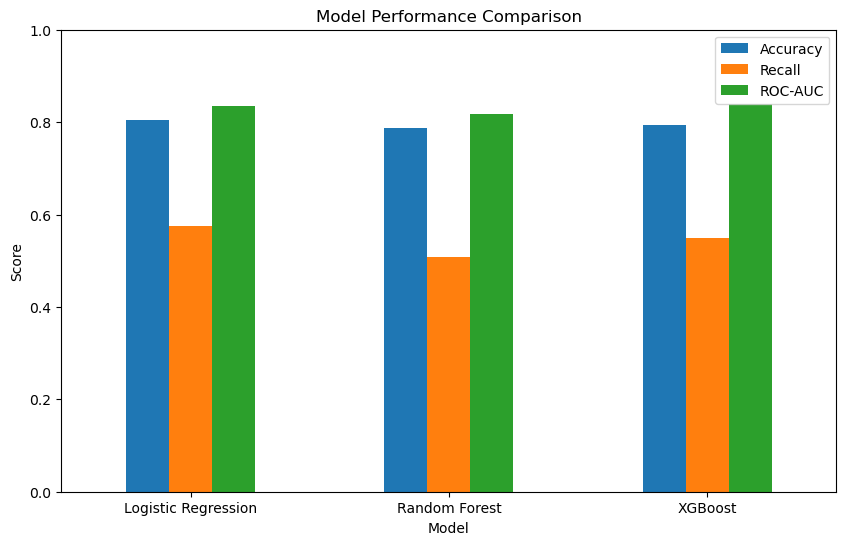

In [64]:
results.set_index('Model')[['Accuracy', 'Recall', 'ROC-AUC']].plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend()
plt.show()

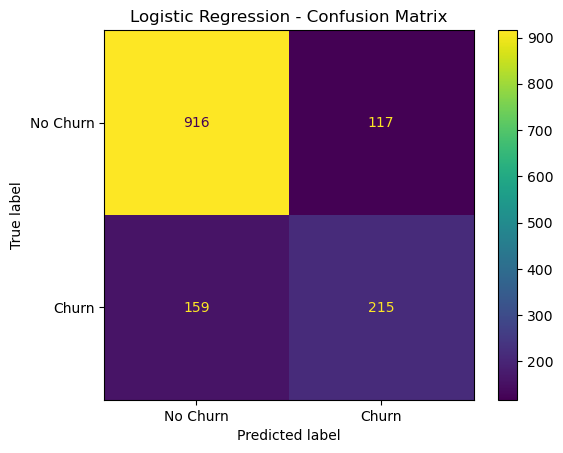

In [65]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Churn', 'Churn']
)

disp.plot()
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

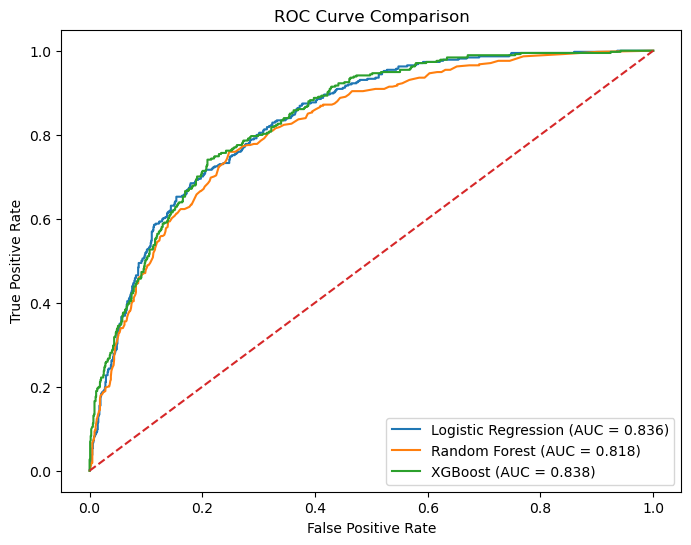

In [66]:
from sklearn.metrics import roc_curve

lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8, 6))

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_roc_auc:.3f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [67]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

In [68]:
feature_importance.head(10)

InternetService_Fiber optic       0.226437
Contract_One year                 0.214339
Contract_Two year                 0.206334
InternetService_No                0.067958
tenure                            0.051582
StreamingMovies_Yes               0.026008
OnlineSecurity_Yes                0.023634
PaymentMethod_Electronic check    0.019914
TechSupport_Yes                   0.016289
PaperlessBilling_Yes              0.015403
dtype: float32

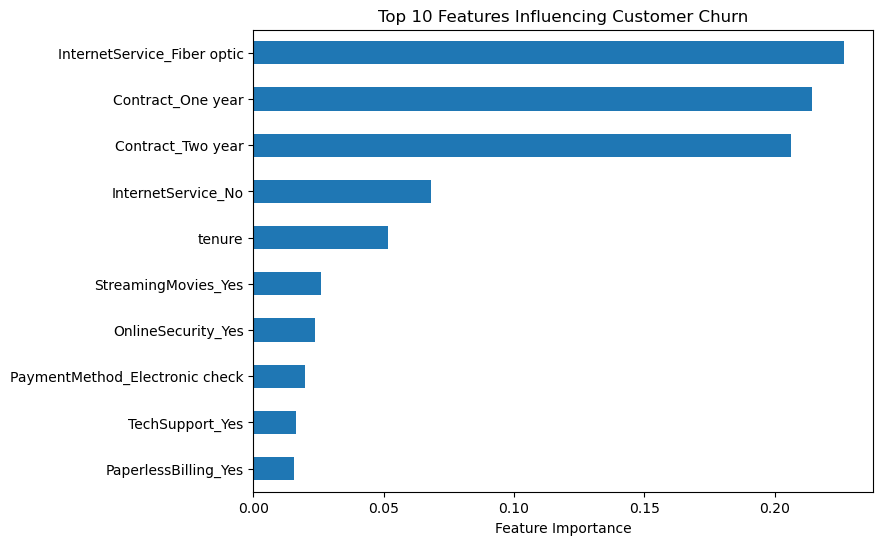

In [69]:
feature_importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(8, 6)
)

plt.title('Top 10 Features Influencing Customer Churn')
plt.xlabel('Feature Importance')
plt.show()

In [70]:
final_model = logistic_model

print("Final Model: Logistic Regression")
print("Accuracy:", round(accuracy, 4))
print("Recall:", round(recall, 4))
print("ROC-AUC:", round(roc_auc, 4))

Final Model: Logistic Regression
Accuracy: 0.8038
Recall: 0.5749
ROC-AUC: 0.8357


In [71]:
!pip install joblib

In [72]:
import joblib

In [73]:
joblib.dump(final_model, 'churn_model.pkl')

['churn_model.pkl']

In [74]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [75]:
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']

In [76]:
sample_customer = X_test.iloc[0:1]

sample_scaled = scaler.transform(sample_customer)

prediction = final_model.predict(sample_scaled)[0]

probability = final_model.predict_proba(sample_scaled)[0][1]

print("Prediction:", "Churn" if prediction == 1 else "No Churn")
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: No Churn
Churn Probability: 1.71 %


In [77]:
final_model = logistic_model

print("Final Model: Logistic Regression")
print("Accuracy:", round(accuracy, 4))
print("Recall:", round(recall, 4))
print("ROC-AUC:", round(roc_auc, 4))

Final Model: Logistic Regression
Accuracy: 0.8038
Recall: 0.5749
ROC-AUC: 0.8357


In [78]:
!pip install joblib

In [79]:
import joblib

joblib.dump(final_model, 'churn_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

['feature_names.pkl']

In [81]:
sample_customer = X_test.iloc[0:1]

sample_scaled = scaler.transform(sample_customer)

prediction = final_model.predict(sample_scaled)[0]
probability = final_model.predict_proba(sample_scaled)[0][1]

print("Prediction:", "Churn" if prediction == 1 else "No Churn")
print("Churn Probability:", round(probability * 100, 2), "%")

Prediction: No Churn
Churn Probability: 1.71 %


In [82]:
import joblib

joblib.dump(final_model, "churn_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [83]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'churn_model.pkl', 'Customer_Churn_Prediction.ipynb', 'feature_names.pkl', 'scaler.pkl']


In [84]:
print(X_train.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
